#### 얼굴인식

In [1]:
from PIL import Image
import glob
import numpy as np

In [20]:
widthRatio = []
heightRatio = []

for file in sorted(glob.glob('../Data/Face/Aiden/*jpg')):
    img = np.array(Image.open(file), dtype=np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

In [30]:
print(f'Aiden의 너비 평균 해상도 : {np.mean(widthRatio)}')
print(f'Aiden의 높이 평균 해상도 : {np.mean(heightRatio)}')

Aiden의 너비 평균 해상도 : 267.1666666666667
Aiden의 높이 평균 해상도 : 295.72222222222223


In [24]:
widthRatio = []
heightRatio = []

for file in sorted(glob.glob('../Data/Face/Andrew/*jpg')):
    img = np.array(Image.open(file), dtype=np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

In [31]:
print(f'Andrew의 너비 평균 해상도 : {np.mean(widthRatio)}')
print(f'Andrew의 높이 평균 해상도 : {np.mean(heightRatio)}')

Andrew의 너비 평균 해상도 : 267.1666666666667
Andrew의 높이 평균 해상도 : 295.72222222222223


In [32]:
widthRatio = []
heightRatio = []

for file in sorted(glob.glob('../Data/Face/Cathy/*.jpg')):
    img = np.array(Image.open(file), dtype=np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

print(f'Cathy의 너비 평균 해상도 : {np.mean(widthRatio)}')
print(f'Cathy의 높이 평균 해상도 : {np.mean(heightRatio)}')

Cathy의 너비 평균 해상도 : 267.1666666666667
Cathy의 높이 평균 해상도 : 295.72222222222223


> 너비 270, 높이 300으로 해상도를 통일하자

- 이미지 해상도 변경 및 흑백으로 저장

In [33]:
# Aiden 사진
i = 1
for file in sorted(glob.glob('../Data/Face/Aiden/*.jpg')):
    img = Image.open(file)
    imgResize = img.resize((270, 300), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f'../Data/Face/Aiden_mono/image_{i:03}.jpg', 'JPEG')
    i+=1

In [34]:
# Andrew 사진
i = 1
for file in sorted(glob.glob('../Data/Face/Andrew/*.jpg')):
    img = Image.open(file)
    imgResize = img.resize((270, 300), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f'../Data/Face/Andrew_mono/image_{i:03}.jpg', 'JPEG')
    i+=1

In [35]:
# Cathy 사진
i = 1
for file in sorted(glob.glob('../Data/Face/Cathy/*.jpg')):
    img = Image.open(file)
    imgResize = img.resize((270, 300), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f'../Data/Face/Cathy_mono/image_{i:03}.jpg', 'JPEG')
    i+=1

- 이미지 Numpy Array로 변경

In [36]:
number_of_data = 18
img_width_size = 270
img_height_size = 300

In [37]:
# Converting "Aiden" Image data to numpy array
aidenData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype=np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)
aidenData.shape

(18, 300, 270)

In [38]:
# Converting "Andrew" Image data to numpy array
andrewData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype=np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)
andrewData.shape

(18, 300, 270)

In [39]:
# Converting "Cathy" Image data to numpy array
cathyData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype=np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)
cathyData.shape

(18, 300, 270)

In [40]:
# Aiden
i = 0

for file in sorted(glob.glob('../Data/Face/Aiden_mono/*.jpg')):
    img = np.array(Image.open(file), dtype=np.int32)
    aidenData[i, :, :] = img
    i += 1
aidenData.shape

(18, 300, 270)

In [41]:
# Andrew
i = 0

for file in sorted(glob.glob('../Data/Face/Andrew_mono/*.jpg')):
    img = np.array(Image.open(file), dtype=np.int32)
    andrewData[i, :, :] = img
    i += 1
andrewData.shape

(18, 300, 270)

In [42]:
# Cathy
i = 0

for file in sorted(glob.glob('../Data/Face/Cathy_mono/*.jpg')):
    img = np.array(Image.open(file), dtype=np.int32)
    cathyData[i, :, :] = img
    i += 1
cathyData.shape

(18, 300, 270)

---
#### 이미지 확인

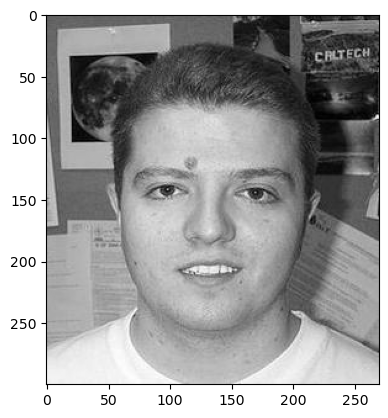

In [45]:
import matplotlib.pyplot as plt

plt.imshow(aidenData[2].reshape(300, 270), cmap='gray')
plt.show()

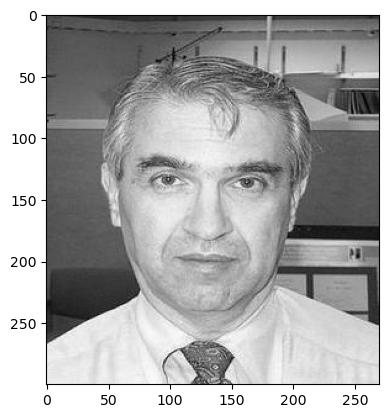

In [46]:
plt.imshow(andrewData[2].reshape(300, 270), cmap='gray')
plt.show()

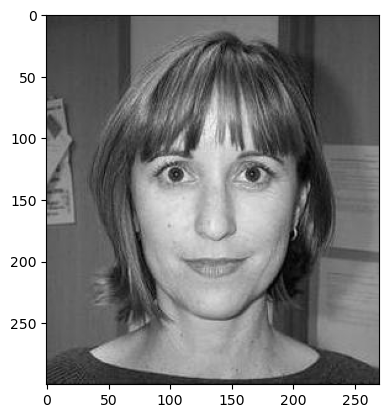

In [47]:
plt.imshow(cathyData[2].reshape(300, 270), cmap='gray')
plt.show()

---
- Train Data로 합치기

In [48]:
train = np.concatenate(
    [
        aidenData,
        andrewData,
        cathyData
    ]
)
train.shape

(54, 300, 270)

---
- Target Data 만들기

In [49]:
target = np.concatenate(
    [
        np.zeros(18),
        np.ones(18),
        np.full(18, 2)
    ]
)
target.shape

(54,)

----
#### CNN으로 데이터 정확도 측정

In [50]:
from tensorflow import keras
from sklearn.model_selection import train_test_split

- 데이터 정규화

In [51]:
train.shape

(54, 300, 270)

In [52]:
train = train.reshape(-1, 300, 270, 1) / 255.0

- Train / Test Data 분리

In [53]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        train,
        target,
        test_size=0.2,
        random_state=42
    )

In [55]:
print(f'Train : {train_input.shape}, {train_target.shape}')
print(f'Test : {test_input.shape}, {test_target.shape}')

Train : (43, 300, 270, 1), (43,)
Test : (11, 300, 270, 1), (11,)


---
- 모델 생성

In [60]:
model = keras.Sequential()

- CNN

In [61]:
model.add(
    keras.layers.Conv2D(
        32,
        kernel_size=3,
        activation='relu',
        padding='same',
        input_shape=(300, 270, 1)
    )
)
model.add(
    keras.layers.MaxPooling2D(2)
)

In [62]:
model.add(
    keras.layers.Conv2D(
        64,
        kernel_size=3,
        activation='relu',
        padding='same',
    )
)
model.add(
    keras.layers.MaxPooling2D(2)
)

- 레이어 생성

In [63]:
# 입력층
model.add(
    keras.layers.Flatten()
)

# 은닉층
model.add(
    keras.layers.Dense(100, activation='relu')
)

# 출력층
model.add(
    keras.layers.Dense(3, activation='softmax')
)

In [65]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 300, 270, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 135, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 135, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 67, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 321600)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │    32,160,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,179,219 (122.75 MB)

 Trainable params: 32,179,219 (122.75 MB)

 Non-trainable params: 0 (0.00 B)

- 손실함수

In [64]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# checkpoint
checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/face_gray_cnn.keras')
# earlystopping
earlystopping_cb = keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
)

- 학습

In [66]:
history = model.fit(
    train_input,
    train_target,
    epochs=50,
    validation_data=(test_input, test_target),
    callbacks=[checkpoint_cb, earlystopping_cb]
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - accuracy: 0.3256 - loss: 2.8162 - val_accuracy: 0.1818 - val_loss: 3.8951
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.3488 - loss: 3.0953 - val_accuracy: 0.5455 - val_loss: 1.1441
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 3s/step - accuracy: 0.5116 - loss: 1.1203 - val_accuracy: 0.5455 - val_loss: 1.2083
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.6977 - loss: 0.7493 - val_accuracy: 0.1818 - val_loss: 1.0615
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.8140 - loss: 0.5465 - val_accuracy: 0.4545 - val_loss: 0.9544
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 1.0000 - loss: 0.2819 - val_accuracy: 0.9091 - val_loss: 0.4419
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.1141 - val_accuracy: 0.7273 - val_loss: 0.5637
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 1.0000 - loss: 0.0453 - val_accuracy: 1.0000 - val_loss: 0.1581
Epoch 9/50
2/2 ━

- 시각화

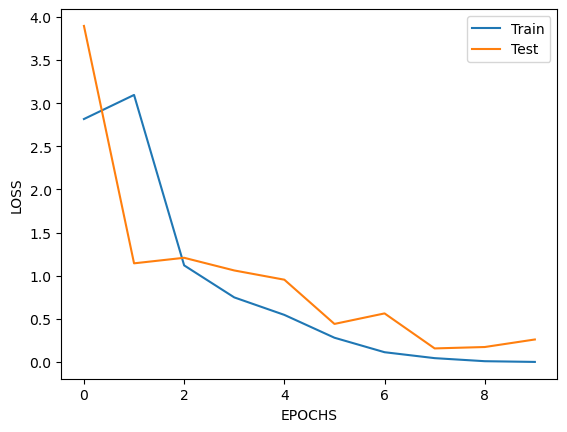

In [67]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('EPOCHS')
plt.ylabel('LOSS')
plt.legend(['Train', 'Test'])
plt.show()

- 평가

In [68]:
model.evaluate(train_input, train_target)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 1.0000 - loss: 0.0110


[0.011009691283106804, 1.0]

In [69]:
model.evaluate(test_input, test_target)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 1.0000 - loss: 0.1581


[0.1580665558576584, 1.0]

> 1차 시도 끝에 훈련값 100%와 시험값 100% 출력

---
- 예측

In [70]:
people = [
    '에이든',
    '앤드류',
    '캐시'
]

In [82]:
pred = model.predict(train_input[41:42])
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([[5.0947850e-04, 6.2098156e-04, 9.9886948e-01]], dtype=float32)

In [83]:
people[np.argmax(pred)]

'캐시'